# RootSage AI — Medicinal Plants Disease Training

This Colab notebook trains on your **medicinal plant *diseases*** dataset (sick/healthy **per disease class**).

**Do not use** the generic `Medicinal plant dataset` folder if that is only plant species without disease labels — use **`Medicinal plant diseases dataset`** (or your disease-labelled folder).

**Recommended model:** EfficientNetV2B0 by default. It is accurate, fast enough for Colab, and deployable. If you have Colab Pro/GPU memory, switch to EfficientNetV2B3 for better accuracy.

The notebook first stages the dataset into Colab local storage under `/content`, then trains from that local copy. This is faster and more stable than reading images directly from Google Drive during every epoch.

Expected dataset on Drive (**Resized Image** — plant → disease folders):

```text
Resized Image/
  Camphor/
    Bacterial Spot/
    Healthy Leaf/
  Neem/
    Powdery Mildew/
    ...
```

The notebook **flattens** this to Keras-friendly classes like `Neem___Powdery_Mildew` (13 classes for your tree).

**Saved model files (fixed names for apps):**

- `medicinal_model.h5`
- `class_names_medicinal.json`
- `training_metadata_medicinal.json`

**Your Google Drive layout:**

```text
My Drive/
  Medicinal plant diseases dataset/
    Resized Image/          # plant → disease → images (this notebook)
  models/                   # medicinal_model.h5 + JSON
```


In [9]:
# Colab setup
from google.colab import drive
drive.mount('/content/drive')

import os, json, shutil, random, zipfile
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Stage Dataset To Colab Local Storage

Loads **`Resized Image`** from Drive (plant → disease subfolders), flattens to one folder per class (`Plant___Disease`), then trains from `/content/RootSage_medicinal_dataset`.

In [11]:
# --- Medicinal-only training config ---
MODEL_FILE_STEM = 'medicinal_model'  # saved as medicinal_model.h5
CLASS_NAMES_FILE = 'class_names_medicinal.json'
METADATA_FILE = 'training_metadata_medicinal.json'

image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def has_image_files(path):
    return any(f.suffix.lower() in image_exts for f in path.rglob('*') if f.is_file())

# --- Drive paths: find "Resized Image" (plant → disease → images) ---
_RESIZED_NAME_HINTS = ('Resized Image', 'resized image', 'Resized image', 'resized_image')
_DRIVE_SEARCH_ROOTS = [
    Path('/content/drive/MyDrive/Medicinal plant diseases dataset'),
    Path('/content/drive/MyDrive/Medicinal plant diseases dataset/Resized Image'),
    Path('/content/drive/MyDrive/models/Resized Image'),
    Path('/content/drive/MyDrive/Medicinal plant diseases dataset/resized image'),
]

def _sanitize_label(text: str) -> str:
    return text.strip().replace(' ', '_')

def find_resized_image_root() -> Path:
    for root in _DRIVE_SEARCH_ROOTS:
        if not root.exists():
            continue
        if root.name in _RESIZED_NAME_HINTS or 'resized' in root.name.lower():
            return root
        for child in root.iterdir():
            if child.is_dir() and (child.name in _RESIZED_NAME_HINTS or 'resized' in child.name.lower()):
                return child
    tried = '\n  - '.join(str(p) for p in _DRIVE_SEARCH_ROOTS)
    raise FileNotFoundError('Could not find Resized Image folder. Checked:\n  - ' + tried)

def is_hierarchical_plant_disease_tree(path: Path) -> bool:
    plants = [p for p in path.iterdir() if p.is_dir() and not p.name.startswith('.')]
    if len(plants) < 2:
        return False
    ok = 0
    for plant in plants:
        diseases = [d for d in plant.iterdir() if d.is_dir()]
        if diseases and any(has_image_files(d) for d in diseases):
            ok += 1
    return ok >= 2

def flatten_resized_image_dataset(src: Path, dst: Path) -> dict:
    """Plant/Disease/imgs → flat class folders Plant___Disease/imgs. Returns {class: count}."""
    if dst.exists():
        shutil.rmtree(dst)
    dst.mkdir(parents=True, exist_ok=True)
    counts = {}
    for plant_dir in sorted(src.iterdir()):
        if not plant_dir.is_dir() or plant_dir.name.startswith('.'):
            continue
        for disease_dir in sorted(plant_dir.iterdir()):
            if not disease_dir.is_dir():
                continue
            class_name = f"{_sanitize_label(plant_dir.name)}___{_sanitize_label(disease_dir.name)}"
            out_dir = dst / class_name
            out_dir.mkdir(parents=True, exist_ok=True)
            n = 0
            for img in disease_dir.rglob('*'):
                if not img.is_file() or img.suffix.lower() not in image_exts:
                    continue
                dest = out_dir / f"{n:05d}_{img.name}"
                shutil.copy2(img, dest)
                n += 1
            if n == 0:
                continue
            counts[class_name] = n
    if len(counts) < 2:
        raise ValueError(f'Flattening produced too few classes ({len(counts)}). Check folder layout under {src}')
    return counts

RESIZED_SOURCE = find_resized_image_root()
print('Found Resized Image on Drive:', RESIZED_SOURCE)
assert is_hierarchical_plant_disease_tree(RESIZED_SOURCE), 'Expected plant → disease subfolders under Resized Image'

LOCAL_DATASET_ROOT = Path('/content/RootSage_medicinal_dataset')
RESET_LOCAL_DATASET = True  # set True after changing dataset on Drive

OUTPUT_DIR = Path('/content/drive/MyDrive/models')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def looks_like_flat_class_root(path: Path) -> bool:
    class_dirs = [p for p in path.iterdir() if p.is_dir()]
    return sum(1 for p in class_dirs if has_image_files(p)) >= 2

if RESET_LOCAL_DATASET and LOCAL_DATASET_ROOT.exists():
    shutil.rmtree(LOCAL_DATASET_ROOT)

if not LOCAL_DATASET_ROOT.exists() or not looks_like_flat_class_root(LOCAL_DATASET_ROOT):
    print('Flattening plant → disease tree into class folders (local)...')
    preview_counts = flatten_resized_image_dataset(RESIZED_SOURCE, LOCAL_DATASET_ROOT)
else:
    print('Using existing flattened local dataset.')
    preview_counts = {}
    for class_dir in sorted(LOCAL_DATASET_ROOT.iterdir()):
        if class_dir.is_dir():
            preview_counts[class_dir.name] = sum(
                1 for f in class_dir.rglob('*') if f.is_file() and f.suffix.lower() in image_exts
            )

DATASET_ROOT = LOCAL_DATASET_ROOT
assert DATASET_ROOT.exists(), f'Local dataset folder not found: {DATASET_ROOT}'

class_dirs = sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir()])
preview_counts = {}
for class_dir in class_dirs:
    preview_counts[class_dir.name] = sum(
        1 for f in class_dir.rglob('*') if f.is_file() and f.suffix.lower() in image_exts
    )
print('Training from local dataset:', DATASET_ROOT)
print('Number of classes:', len(class_dirs))
print('Total images:', sum(preview_counts.values()))
print('Output folder (Drive):', OUTPUT_DIR)
print('\n--- All class folders (alphabetical) ---')
for name in sorted(preview_counts.keys()):
    print(f'  {name}: {preview_counts[name]}')

Found Resized Image on Drive: /content/drive/MyDrive/models/Resized Image
Flattening plant → disease tree into class folders (local)...
Training from local dataset: /content/RootSage_medicinal_dataset
Number of classes: 13
Total images: 10863
Output folder (Drive): /content/drive/MyDrive/models

--- All class folders (alphabetical) ---
  Camphor___Bacterial_Spot: 806
  Camphor___Healthy_Leaf: 800
  Camphor___Shot_Hole: 795
  HariTaki___Bacterial_Spot: 803
  HariTaki___Healthy_Leaf: 816
  HariTaki___Shot_Hole: 802
  Neem___Healthy_Leaf: 1021
  Neem___Powdery_Mildew: 854
  Neem___Shot_Hole_Leaf: 834
  Neem___Yellow_Leaf: 854
  Sojina___Bacterial_Spot: 804
  Sojina___Healthy_Leaf: 860
  Sojina___Yellow_Leaf: 814


## 2. Dataset Quality Check

This checks class counts. Try to avoid extreme imbalance. If one class has 3000 images and another has 80, training can become biased.

In [12]:
image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
counts = {}
for class_dir in class_dirs:
    counts[class_dir.name] = sum(1 for f in class_dir.rglob('*') if f.suffix.lower() in image_exts)

print('=== Every class (index, name, image count) ===')
for idx, name in enumerate(sorted(counts.keys())):
    print(f'{idx:3d}  {name}: {counts[name]}')

inventory_path = OUTPUT_DIR / 'class_inventory_medicinal.json'
with open(inventory_path, 'w', encoding='utf-8') as f:
    json.dump({'class_names': sorted(counts.keys()), 'counts': counts}, f, indent=2)
print('\nSaved class list + counts to:', inventory_path)
print('Total images:', sum(counts.values()))
print('Smallest class:', min(counts.items(), key=lambda x: x[1]))
print('Largest class:', max(counts.items(), key=lambda x: x[1]))

=== Every class (index, name, image count) ===
  0  Camphor___Bacterial_Spot: 806
  1  Camphor___Healthy_Leaf: 800
  2  Camphor___Shot_Hole: 795
  3  HariTaki___Bacterial_Spot: 803
  4  HariTaki___Healthy_Leaf: 816
  5  HariTaki___Shot_Hole: 802
  6  Neem___Healthy_Leaf: 1021
  7  Neem___Powdery_Mildew: 854
  8  Neem___Shot_Hole_Leaf: 834
  9  Neem___Yellow_Leaf: 854
 10  Sojina___Bacterial_Spot: 804
 11  Sojina___Healthy_Leaf: 860
 12  Sojina___Yellow_Leaf: 814

Saved class list + counts to: /content/drive/MyDrive/models/class_inventory_medicinal.json
Total images: 10863
Smallest class: ('Camphor___Shot_Hole', 795)
Largest class: ('Neem___Healthy_Leaf', 1021)


## 3. Training Settings

Use `efficientnetv2b0` first. If validation accuracy is not enough and Colab memory allows, try `efficientnetv2b3`.

In [13]:
IMG_SIZE = 224
BATCH_SIZE = 32
MODEL_NAME = 'efficientnetv2b0'  # options: efficientnetv2b0, efficientnetv2b3
INITIAL_EPOCHS = 12
FINE_TUNE_EPOCHS = 12
VALIDATION_SPLIT = 0.2

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Classes:', num_classes)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Found 10863 files belonging to 13 classes.
Using 8691 files for training.
Found 10863 files belonging to 13 classes.
Using 2172 files for validation.
Classes: 13


## 4. Class Weights

Class weights help when some medicinal plant classes have far fewer images than others.

In [14]:
total = sum(counts.values())
class_weight = {}
for idx, name in enumerate(class_names):
    class_weight[idx] = total / (num_classes * max(1, counts.get(name, 1)))

print('Sample class weights:')
for idx in range(min(10, num_classes)):
    print(idx, class_names[idx], round(class_weight[idx], 3))

Sample class weights:
0 Camphor___Bacterial_Spot 1.037
1 Camphor___Healthy_Leaf 1.045
2 Camphor___Shot_Hole 1.051
3 HariTaki___Bacterial_Spot 1.041
4 HariTaki___Healthy_Leaf 1.024
5 HariTaki___Shot_Hole 1.042
6 Neem___Healthy_Leaf 0.818
7 Neem___Powdery_Mildew 0.978
8 Neem___Shot_Hole_Leaf 1.002
9 Neem___Yellow_Leaf 0.978


## 5. Build Model With ECA Attention

EfficientNetV2 includes preprocessing internally when `include_preprocessing=True`. For this notebook, deploy with `MODEL_FAMILY=none` because preprocessing is saved inside the model.

This model adds an **Efficient Channel Attention (ECA)** block after the CNN backbone. ECA is lightweight and helps the classifier focus on disease-specific channels such as spots, mildew texture, rust color, and leaf damage patterns. Keep it only if validation accuracy and confusion matrix improve compared with the baseline.


In [15]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.12),
], name='augmentation')

def eca_block(inputs, gamma=2, b=1, name='eca'):
    """Efficient Channel Attention block for CNN feature maps."""
    channels = inputs.shape[-1]
    kernel_size = int(abs((np.log2(float(channels)) + b) / gamma))
    kernel_size = kernel_size if kernel_size % 2 else kernel_size + 1
    kernel_size = max(3, kernel_size)

    x = layers.GlobalAveragePooling2D(name=f'{name}_gap')(inputs)
    x = layers.Reshape((-1, 1), name=f'{name}_reshape_in')(x)
    x = layers.Conv1D(1, kernel_size=kernel_size, padding='same', use_bias=False, name=f'{name}_conv1d')(x)
    x = layers.Activation('sigmoid', name=f'{name}_sigmoid')(x)
    x = layers.Reshape((1, 1, channels), name=f'{name}_reshape_out')(x)
    return layers.Multiply(name=f'{name}_scale')([inputs, x])

if MODEL_NAME == 'efficientnetv2b3':
    base_model = keras.applications.EfficientNetV2B3(
        include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3), include_preprocessing=True
    )
else:
    base_model = keras.applications.EfficientNetV2B0(
        include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3), include_preprocessing=True
    )

base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = eca_block(x, name='disease_eca')
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(inputs, outputs, name=f'RootSage_medicinal_{MODEL_NAME}_ECA')

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy')]
)

model.summary()


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "RootSage_medicinal_efficientnetv2b0_ECA"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 7, 7,      │  5,919,312 │ augmentation[0][… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease_eca_gap     │ (None, 1280)      │          0 │ efficientnetv2-b… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease_eca_reshap… │ (None, 1280, 1)   │          0 │ disease_eca_gap[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease_eca_conv1d  │ (None, 1280, 1)   │          5 │ disease_eca_resh… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease_eca_sigmoid │ (None, 1280, 1)   │          0 │ disease_eca_conv… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease_eca_reshap… │ (None, 1, 1,      │          0 │ disease_eca_sigm… │
│ (Reshape)           │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease_eca_scale   │ (None, 7, 7,      │          0 │ efficientnetv2-b… │
│ (Multiply)          │ 1280)             │            │ disease_eca_resh… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ disease_eca_scal… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1280)      │      5,120 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 13)        │     16,653 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,941,090 (22.66 MB)

 Trainable params: 19,218 (75.07 KB)

 Non-trainable params: 5,921,872 (22.59 MB)

## 6. Train Classifier Head

In [16]:
checkpoint_path = OUTPUT_DIR / f'{MODEL_FILE_STEM}_best.keras'

callbacks = [
    keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.35, patience=2, min_lr=1e-6, verbose=1),
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/12
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5508 - loss: 1.3274 - top3_accuracy: 0.8299
Epoch 1: val_accuracy improved from None to 0.81630, saving model to /content/drive/MyDrive/models/medicinal_model_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/models/medicinal_model_best.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 85s 132ms/step - accuracy: 0.6855 - loss: 0.8729 - top3_accuracy: 0.9322 - val_accuracy: 0.8163 - val_loss: 0.7539 - val_top3_accuracy: 0.9913 - learning_rate: 0.0010
Epoch 2/12
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8276 - loss: 0.4740 - top3_accuracy: 0.9876
Epoch 2: val_accuracy improved from 0.81630 to 0.85912, saving model to /content/drive/MyDrive/models/medicinal_model_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/models/medicinal_model_best.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 22s 82ms/step - accuracy: 0.8393 - loss: 0.4434 - top3_accuracy: 0.9891 - val_accuracy: 0.8591 - val_loss: 0.3623 

## 7. Fine-Tune Model

Fine-tuning the last layers improves accuracy on plant disease textures. If overfitting starts, reduce `FINE_TUNE_LAYERS` or epochs.

In [17]:
FINE_TUNE_LAYERS = 45
base_model.trainable = True

for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=2e-5, weight_decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy')]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS + FINE_TUNE_EPOCHS,
    initial_epoch=len(history_head.history['loss']),
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 13/24
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8400 - loss: 0.4344 - top3_accuracy: 0.9893
Epoch 13: val_accuracy did not improve from 0.92541
272/272 ━━━━━━━━━━━━━━━━━━━━ 56s 117ms/step - accuracy: 0.8557 - loss: 0.3984 - top3_accuracy: 0.9914 - val_accuracy: 0.8844 - val_loss: 0.3148 - val_top3_accuracy: 0.9963 - learning_rate: 2.0000e-05
Epoch 14/24
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8674 - loss: 0.3758 - top3_accuracy: 0.9918
Epoch 14: val_accuracy did not improve from 0.92541

Epoch 14: ReduceLROnPlateau reducing learning rate to 6.9999998231651255e-06.
272/272 ━━━━━━━━━━━━━━━━━━━━ 27s 99ms/step - accuracy: 0.8724 - loss: 0.3570 - top3_accuracy: 0.9933 - val_accuracy: 0.9042 - val_loss: 0.2676 - val_top3_accuracy: 0.9972 - learning_rate: 2.0000e-05
Epoch 15/24
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8738 - loss: 0.3426 - top3_accuracy: 0.9955
Epoch 15: val_accuracy did not improve from 0.92541
272/272 ━━━━━━━━━━━━━━━━━━━━ 2

## 8. Evaluate

In [18]:
results_dict = model.evaluate(val_ds, verbose=1, return_dict=True)
print(results_dict)

val_accuracy = None
if isinstance(results_dict, dict):
    if 'accuracy' in results_dict:
        val_accuracy = float(results_dict['accuracy'])
    else:
        for k, v in results_dict.items():
            if 'accuracy' in str(k).lower() and 'top' not in str(k).lower():
                val_accuracy = float(v)
                break

print('Validation accuracy:', val_accuracy)

68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.8844 - loss: 0.3148 - top3_accuracy: 0.9963
{'accuracy': 0.8844382762908936, 'loss': 0.31483912467956543, 'top3_accuracy': 0.9963167309761047}
Validation accuracy: 0.8844382762908936


## 9. Save model to Drive `models/` folder

Saves to `My Drive/models/` (same folder you already have), then copy into `plant-disease/models/` on your PC.

In [21]:
h5_path = OUTPUT_DIR / f'{MODEL_FILE_STEM}.h5'
keras_path = OUTPUT_DIR / f'{MODEL_FILE_STEM}.keras'
class_path = OUTPUT_DIR / CLASS_NAMES_FILE
meta_path = OUTPUT_DIR / METADATA_FILE

def _get_val_accuracy():
    if 'val_accuracy' in dir():
        return float(val_accuracy)
    if 'results_dict' in dir() and isinstance(results_dict, dict):
        if 'accuracy' in results_dict:
            return float(results_dict['accuracy'])
        for k, v in results_dict.items():
            if 'accuracy' in str(k).lower() and 'top' not in str(k).lower():
                return float(v)
    return None

val_acc = _get_val_accuracy()

_drive_src = globals().get('DRIVE_DATASET_PATH') or globals().get('DRIVE_DATASET_SOURCE')
if _drive_src is None:
    _drive_src = str(globals().get('drive_src', 'unknown'))

model.save(keras_path)  # native Keras format (recommended)
model.save(h5_path)     # .h5 for farmer_app / Streamlit (HDF5 warning is OK)
with open(class_path, 'w', encoding='utf-8') as f:
    json.dump({'class_names': class_names}, f, indent=2)

metadata = {
    'task': 'medicinal_plants_only',
    'backbone': MODEL_NAME,
    'model_file_h5': MODEL_FILE_STEM + '.h5',
    'model_file_keras': MODEL_FILE_STEM + '.keras',
    'image_size': IMG_SIZE,
    'num_classes': num_classes,
    'validation_split': VALIDATION_SPLIT,
    'initial_epochs': INITIAL_EPOCHS,
    'fine_tune_epochs': FINE_TUNE_EPOCHS,
    'dataset_root': str(DATASET_ROOT),
    'drive_dataset_source': str(_drive_src),
    'drive_output_dir': str(OUTPUT_DIR),
    'val_accuracy': val_acc,
}
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Saved model (keras):', keras_path)
print('Saved model (h5):', h5_path)
print('Saved classes:', class_path)
print('Saved metadata:', meta_path)
print('Class count:', len(class_names))
print('\nCopy to local repo:')
print('  plant-disease/models/' + h5_path.name)
print('  plant-disease/models/' + CLASS_NAMES_FILE)

Saved model (keras): /content/drive/MyDrive/models/medicinal_model.keras
Saved model (h5): /content/drive/MyDrive/models/medicinal_model.h5
Saved classes: /content/drive/MyDrive/models/class_names_medicinal.json
Saved metadata: /content/drive/MyDrive/models/training_metadata_medicinal.json
Class count: 13

Copy to local repo:
  plant-disease/models/medicinal_model.h5
  plant-disease/models/class_names_medicinal.json


## 10. Test Single Image

Upload or point to a test leaf image.

Saving White Spot_IMG_20241108_185907.jpg.jpg to White Spot_IMG_20241108_185907.jpg.jpg


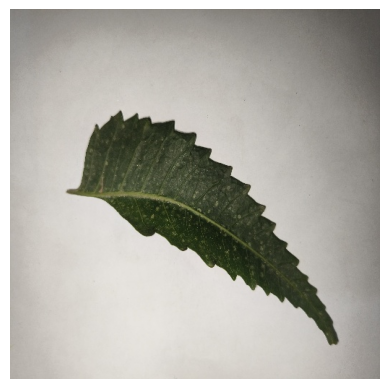

Neem___Powdery_Mildew 0.9993601441383362
Neem___Shot_Hole_Leaf 0.0002842367684934288
Neem___Healthy_Leaf 0.00017706419748719782


In [22]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()
test_path = next(iter(uploaded.keys()))

img = keras.utils.load_img(test_path, target_size=(IMG_SIZE, IMG_SIZE))
arr = keras.utils.img_to_array(img)
batch = np.expand_dims(arr, axis=0)
pred = model.predict(batch, verbose=0)[0]
top_idx = pred.argsort()[-3:][::-1]

plt.imshow(Image.open(test_path))
plt.axis('off')
plt.show()

for idx in top_idx:
    print(class_names[idx], float(pred[idx]))

## 11. Use in local project (farmer app / Streamlit)

After Colab finishes, download from **My Drive → models** and place files here:

```text
plant-disease/models/medicinal_model.h5
plant-disease/models/class_names_medicinal.json
plant-disease/models/training_metadata_medicinal.json
```

**Farmer app (PowerShell):**

```powershell
$env:FARMER_MODEL_PATH="C:\Users\Ashrith\Desktop\plant-disease\models\medicinal_model.h5"
$env:FARMER_CLASS_JSON="C:\Users\Ashrith\Desktop\plant-disease\models\class_names_medicinal.json"
streamlit run farmer_app/app.py
```

EfficientNetV2 includes preprocessing inside the saved model — use raw RGB uploads (0–255), no extra `preprocess_input` in the app.